# 04 · Diagnostic EDA — relationships, outliers & one impossible-looking fact
### The Outliers · Mumbai Rent Radar

Descriptive EDA showed the *shape*. Now we ask **why** rent moves — which features
actually carry the price, which outliers are typos, and whether the data hides
something that sounds wrong but is true. Each chart below makes exactly one point.

**Input:** `data/processed/listings_imputed.csv` + locality attributes

In [2]:
import sys, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.ticker import FuncFormatter
import style
warnings.filterwarnings("ignore")
style.setup()

df = pd.read_csv("../data/processed/listings_imputed.csv")
att = pd.read_csv("../data/processed/locality_attributes.csv")
m = df.merge(att, on="locality_name", how="left", suffixes=("", "_a"))
m["rent_per_sqft"] = m["rent"] / m["size"]
m["log_rent"] = np.log(m["rent"])
print("Merged rows:", len(m))

Merged rows: 5000


## 1 · What actually carries the price?
The correlation of each feature with **log(rent)**. The result is stark — and sets up
the whole modelling strategy.

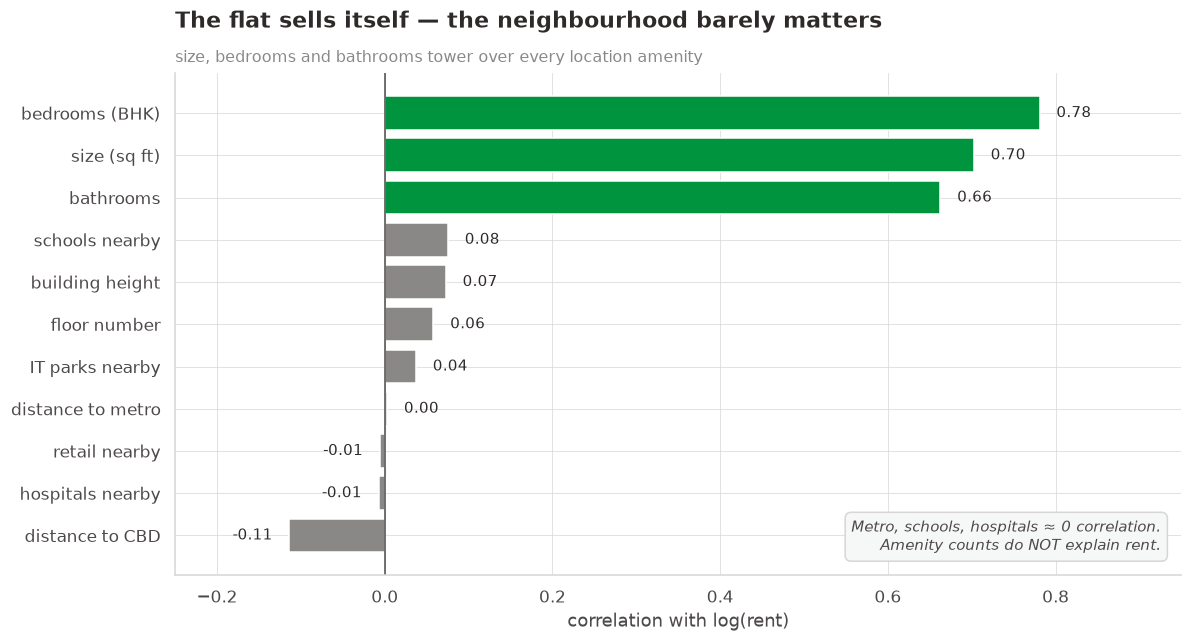

In [3]:
num = ["bhk", "size", "bathroom", "total_floors", "floor_num", "school_count_2km",
       "it_park_count_5km", "nearest_metro_km", "retail_count_2km", "hospital_count_2km",
       "distance_to_cbd_km"]
num = [c for c in num if c in m.columns]
corr = m[num + ["log_rent"]].corr()["log_rent"].drop("log_rent").sort_values()
labels = {"bhk": "bedrooms (BHK)", "size": "size (sq ft)", "bathroom": "bathrooms",
          "total_floors": "building height", "floor_num": "floor number",
          "school_count_2km": "schools nearby", "it_park_count_5km": "IT parks nearby",
          "nearest_metro_km": "distance to metro", "retail_count_2km": "retail nearby",
          "hospital_count_2km": "hospitals nearby", "distance_to_cbd_km": "distance to CBD"}
colors = [style.GREEN if abs(v) > 0.3 else style.GREY for v in corr.values]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh([labels.get(i, i) for i in corr.index], corr.values, color=colors)
for i, v in enumerate(corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=10, color=style.INK)
ax.axvline(0, color=style.CHARCOAL, lw=1)
ax.set_xlim(-0.25, 0.95); ax.set_xlabel("correlation with log(rent)")
style.title(ax, "The flat sells itself — the neighbourhood barely matters",
            "size, bedrooms and bathrooms tower over every location amenity")
style.note(ax, "Metro, schools, hospitals ≈ 0 correlation.\nAmenity counts do NOT explain rent.", where="lower right")
fig.tight_layout(); style.save(fig, "04_corr_with_rent"); plt.show()

**Insight:** the three strongest signals are all *physical* (BHK 0.78, size 0.70, baths 0.66);
every location amenity sits near zero. **Decision:** the model leans on the flat's own
features; location must enter as an *identity* (which locality), not as amenity counts.

## 2 · The impossible-looking fact 🔍
Common sense says: a flat next to an **operational metro** should cost more. The data says
the opposite — and it is real, not a glitch.

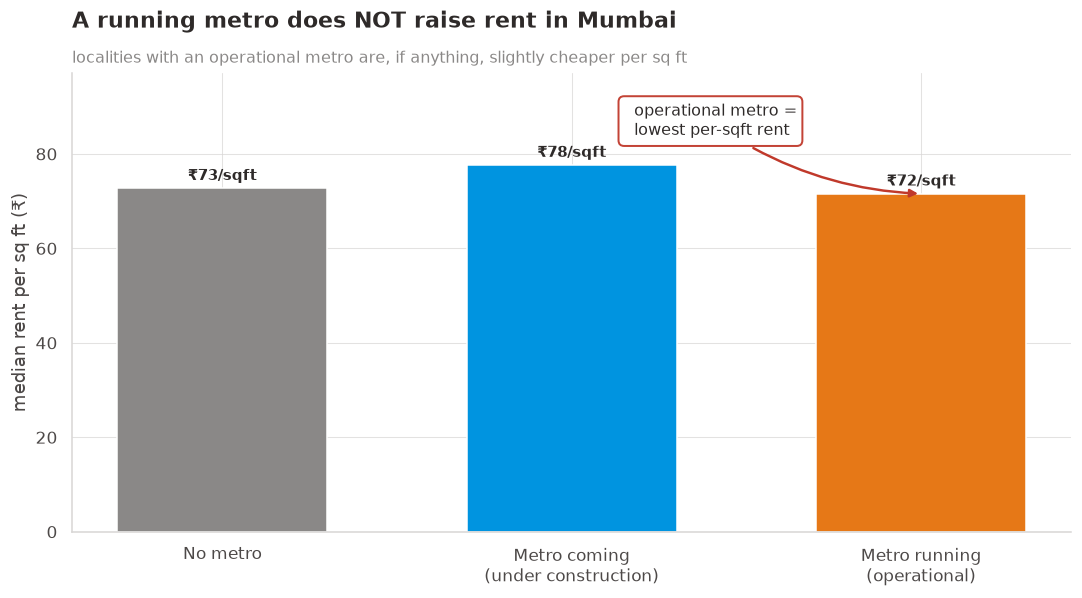

In [4]:
mmet = m[m["metro_status"].notna()]
g = mmet.groupby("metro_status")["rent_per_sqft"].median().reindex(
    ["none", "under_construction", "operational"])
lab = {"none": "No metro", "under_construction": "Metro coming\n(under construction)", "operational": "Metro running\n(operational)"}
fig, ax = plt.subplots(figsize=(10, 5.6))
bars = ax.bar([lab[i] for i in g.index], g.values,
              color=[style.GREY, style.BLUE, style.ORANGE], width=0.6)
style.bar_labels(ax, fmt="₹{:.0f}/sqft")
ax.set_ylabel("median rent per sq ft (₹)"); ax.set_ylim(0, g.max() * 1.25)
style.title(ax, "A running metro does NOT raise rent in Mumbai",
            "localities with an operational metro are, if anything, slightly cheaper per sq ft")
style.callout(ax, (2, g["operational"]), "  operational metro =\n  lowest per-sqft rent",
              xytext=(1.15, g.max() * 1.12), color=style.BAD)
fig.tight_layout(); style.save(fig, "04_metro_paradox"); plt.show()

**Why it's true (not a bug):** Mumbai's operational metro lines run through mid-income
suburbs (Andheri–Ghatkopar), while the priciest addresses — Malabar Hill, Breach Candy,
Bandra's sea face — grew rich *without* a metro. So "metro access" is entangled with
"not-the-posh-pocket." **Decision:** don't feed raw metro flags to the model as a premium
signal; the locality's own price level already captures what buyers pay for.

## 3 · A second surprise: bigger flats cost *more* per square foot
For most goods, buying in bulk is cheaper per unit. Mumbai rent inverts this.

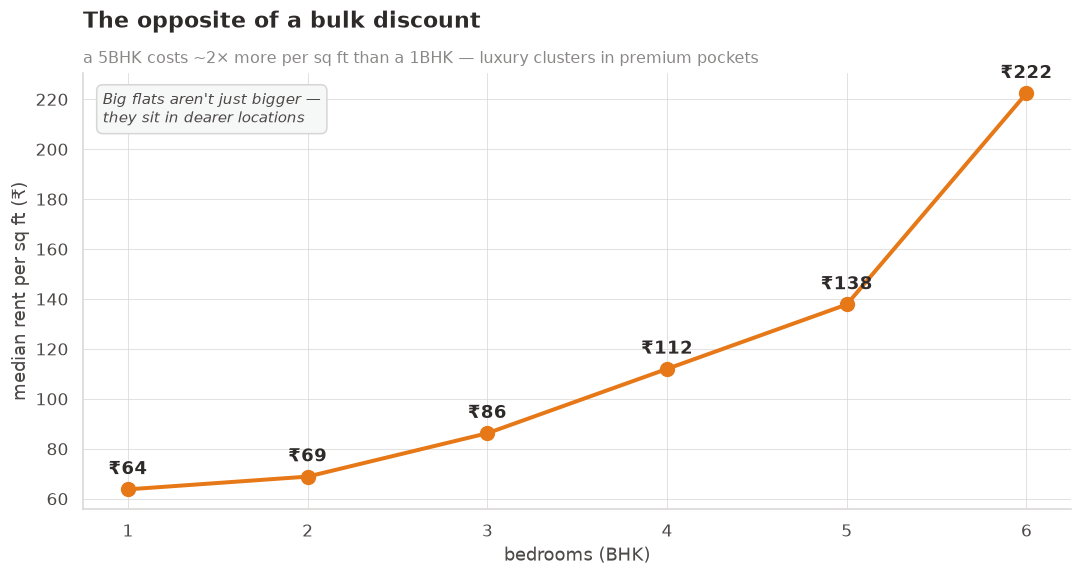

In [5]:
rps_bhk = m[m.bhk <= 6].groupby("bhk")["rent_per_sqft"].median()
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.plot(rps_bhk.index, rps_bhk.values, "-o", color=style.ORANGE, lw=2.6, ms=9)
for x, y in rps_bhk.items():
    ax.annotate(f"₹{y:.0f}", (x, y), textcoords="offset points", xytext=(0, 10),
                ha="center", fontweight="bold", color=style.INK)
ax.set_xlabel("bedrooms (BHK)"); ax.set_ylabel("median rent per sq ft (₹)")
style.title(ax, "The opposite of a bulk discount",
            "a 5BHK costs ~2× more per sq ft than a 1BHK — luxury clusters in premium pockets")
style.note(ax, "Big flats aren't just bigger —\nthey sit in dearer locations", where="upper left")
fig.tight_layout(); style.save(fig, "04_rps_by_bhk"); plt.show()

**Insight:** per-sqft rent nearly doubles from 1BHK to 5BHK. Large homes aren't priced by
the foot — they're priced by the *address* they occupy. **Decision:** rent-per-sqft is a
useful engineered feature, but must be read alongside locality.

## 4 · Size drives rent — with typos hiding in the tail
The core relationship, shown as density (hexbin) so 5,000 points don't smear into a blob.

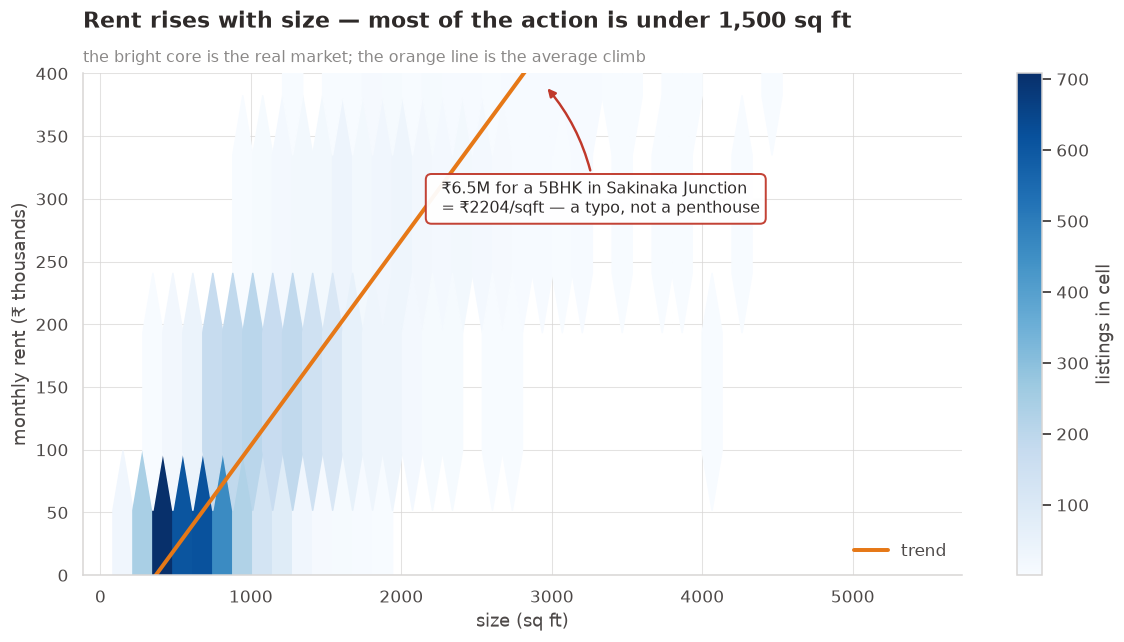

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))
sub = m[(m["size"] < 6000)]
hb = ax.hexbin(sub["size"], sub["rent"] / 1000, gridsize=40, cmap="Blues", mincnt=1)
z = np.polyfit(sub["size"], sub["rent"] / 1000, 1)
xs = np.linspace(sub["size"].min(), sub["size"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=style.ORANGE, lw=2.6, label="trend")
ax.set_ylim(0, 400); ax.set_xlabel("size (sq ft)"); ax.set_ylabel("monthly rent (₹ thousands)")
fig.colorbar(hb, ax=ax, label="listings in cell")
# flag the impossible listing
big = m.loc[m["rent"].idxmax()]
style.callout(ax, (big["size"], 390), f"  ₹{big['rent']/1e6:.1f}M for a 5BHK in {big['locality_name']}\n  = ₹{big['rent']/big['size']:.0f}/sqft — a typo, not a penthouse",
              xytext=(2200, 300), color=style.BAD)
style.title(ax, "Rent rises with size — most of the action is under 1,500 sq ft",
            "the bright core is the real market; the orange line is the average climb")
ax.legend(loc="lower right")
fig.tight_layout(); style.save(fig, "04_size_vs_rent"); plt.show()

## 5 · Outlier audit: typos vs genuine penthouses
We fence rent-per-sqft with the IQR rule. Values far outside are almost always data-entry
errors (a missing digit in size, or an extra zero in rent) — not real luxury.

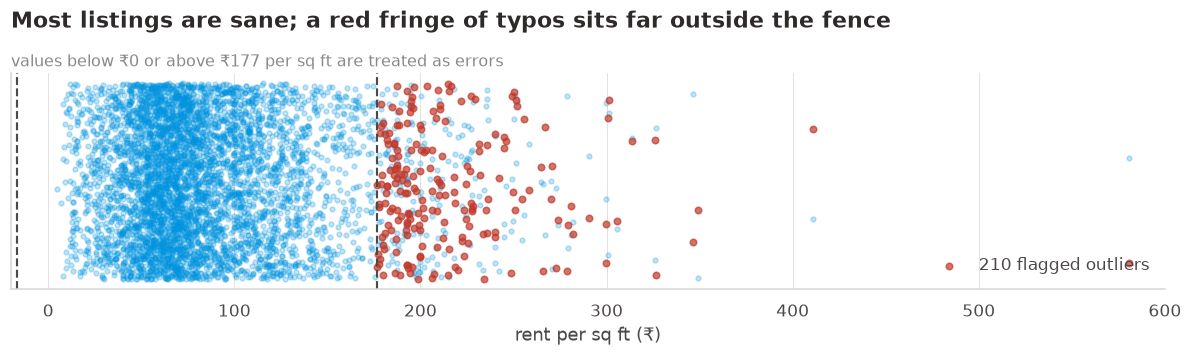

Flagged 210 outlier listings (4.2%). Examples:
listing_id      rent   size  bhk     locality_name  rent_per_sqft
 LST104119 6520000.0 2958.0    5 Sakinaka Junction         2204.0
 LST100709 1600000.0 1100.0    3    Santacruz West         1455.0
 LST100079 1500000.0 1500.0    3       Turner Road         1000.0
 LST101932  660000.0  703.0    2          Bhoiwada          939.0
 LST103327  735000.0  900.0    2  Park Site Colony          817.0


In [7]:
q1, q3 = m["rent_per_sqft"].quantile([0.25, 0.75]); iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
out = m[(m["rent_per_sqft"] < lo) | (m["rent_per_sqft"] > hi)]
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.scatter(m["rent_per_sqft"], np.zeros(len(m)) + np.random.uniform(-1, 1, len(m)),
           s=10, color=style.BLUE, alpha=0.25)
ax.scatter(out["rent_per_sqft"], np.random.uniform(-1, 1, len(out)),
           s=18, color=style.BAD, alpha=0.7, label=f"{len(out)} flagged outliers")
ax.axvline(hi, color=style.CHARCOAL, ls="--", lw=1.4)
ax.axvline(lo, color=style.CHARCOAL, ls="--", lw=1.4)
ax.set_xlim(-20, 600); ax.set_yticks([]); ax.set_xlabel("rent per sq ft (₹)")
style.callout(ax, (hi, 1.3), f"  IQR fence ₹{hi:.0f}/sqft", xytext=(hi + 60, 1.6), color=style.CHARCOAL)
style.title(ax, "Most listings are sane; a red fringe of typos sits far outside the fence",
            "values below ₹{:.0f} or above ₹{:.0f} per sq ft are treated as errors".format(max(lo,0), hi))
ax.legend(loc="lower right")
fig.tight_layout(); style.save(fig, "04_outliers"); plt.show()

print(f"Flagged {len(out)} outlier listings ({len(out)/len(m)*100:.1f}%). Examples:")
print(out.nlargest(5, "rent_per_sqft")[["listing_id", "rent", "size", "bhk", "locality_name", "rent_per_sqft"]].round(0).to_string(index=False))

**Decision:** cap rent-per-sqft at the IQR fences for feature engineering (winsorise, don't
delete) — we keep the row's other honest information while stopping a typo from bending the model.

## 6 · The full correlation map
One compact matrix to see how every numeric feature relates — including the ones that don't.

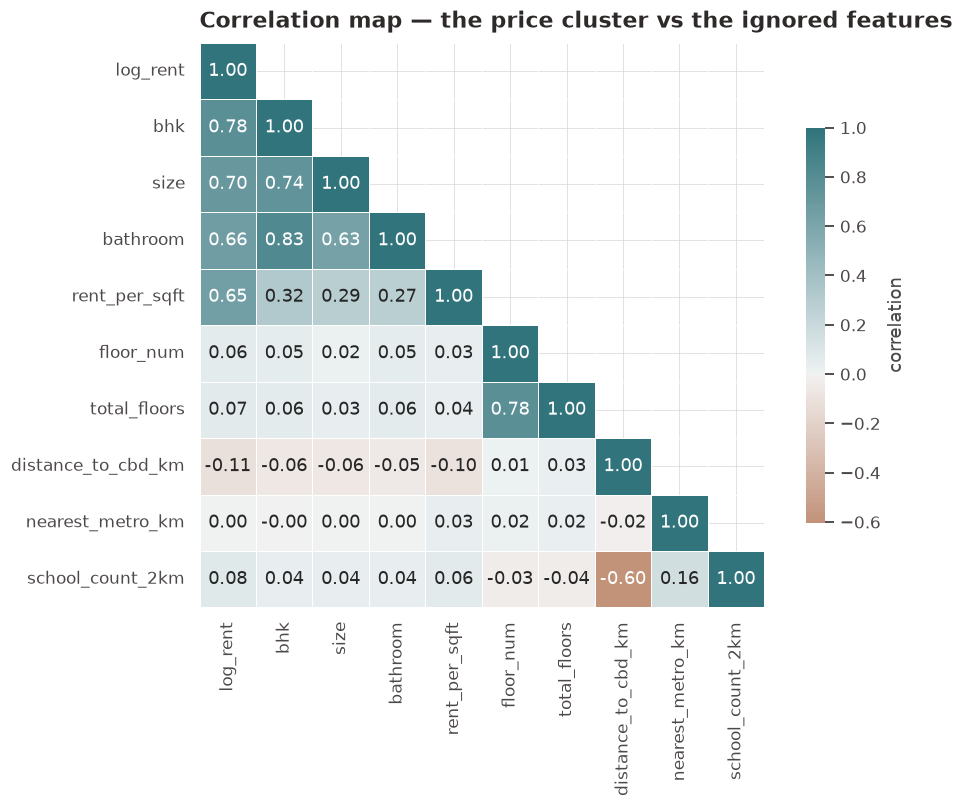

In [8]:
cm = m[["log_rent", "bhk", "size", "bathroom", "rent_per_sqft", "floor_num",
        "total_floors", "distance_to_cbd_km", "nearest_metro_km", "school_count_2km"]].corr()
fig, ax = plt.subplots(figsize=(9.5, 7.5))
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, mask=mask, annot=True, fmt=".2f", cmap=style.DIVERGING, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .7, "label": "correlation"}, ax=ax)
style.title(ax, "Correlation map — the price cluster vs the ignored features")
fig.tight_layout(); style.save(fig, "04_corr_matrix"); plt.show()

### Diagnostic takeaways
- **Physical features rule.** BHK, size and bathrooms carry rent; amenity counts do not.
- **Two facts that sound wrong but aren't:** a running metro is not a premium, and bigger
  flats cost *more* per sq ft — both because luxury is about *address*, not amenities.
- **Typos, not penthouses.** A handful of extreme per-sqft values are data errors; we
  winsorise rather than delete.
- **Implication for the model:** a ceiling near R²≈0.7 is expected from physical features
  alone; the locality identity is where extra signal must come from.